In [1]:
%pip install spacy


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
!{sys.executable} -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta 


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install nltk spacy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
import spacy

In [5]:
%pip install "pandas==2.2.3" "pyarrow==17.0.0"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
nltk.download('stopwords')
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])  # keep only tagger+lemmatizer, faster

import pyarrow.parquet as pq

df = pq.read_table('DATASET.parquet').to_pandas()
print(df.shape)
print(df['label'].value_counts().sort_index())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shivd\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


(25000, 2)
label
0    3614
1    3357
2    2099
3     204
4     705
5    1730
6    5408
7    5321
8    2562
Name: count, dtype: int64


In [7]:
def basic_clean(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s\.\,\-]', ' ', text)   # keep basic punctuation, strip weird symbols
    text = re.sub(r'\s+', ' ', text).strip()          # collapse whitespace
    return text

df['text_clean'] = df['text'].apply(basic_clean)

In [23]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return ' '.join(w for w in text.split() if w not in stop_words)

df['text_clean'] = df['text_clean'].apply(remove_stopwords)

In [9]:
def lemmatize_batch(texts, batch_size=64):
    lemmatized = []
    for doc in nlp.pipe(texts, batch_size=batch_size):
        lemmatized.append(' '.join(tok.lemma_ for tok in doc if not tok.is_space))
    return lemmatized


In [10]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df, test_size=0.15, stratify=df['label'], random_state=42
)
print(train_df['label'].value_counts().sort_index())
print(val_df['label'].value_counts().sort_index())

label
0    3072
1    2853
2    1784
3     173
4     599
5    1471
6    4597
7    4523
8    2178
Name: count, dtype: int64
label
0    542
1    504
2    315
3     31
4    106
5    259
6    811
7    798
8    384
Name: count, dtype: int64


In [13]:
print("First 5 cleaned training values:\n")
print(train_df['text_clean'].head(5).to_string(index=True))

First 5 cleaned training values:

13791    attached drawings illustrating embodiments inv...
21167    matrix 1 depicted fig1 within central area , p...
23331    following examples illustrate present inventio...
14942    medical instrument 10 fig1 directed placement ...
8812     referring fig1 solid fuel heating appliance co...


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))

# fit ONLY on train, then transform both
X_train = vectorizer.fit_transform(train_df['text_clean'])
X_val = vectorizer.transform(val_df['text_clean'])

# save it so SVM training script can just load it later
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

In [15]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, f1_score

y_train = train_df['label']
y_val = val_df['label']

model_a = SGDClassifier(loss='hinge', penalty='l2', alpha=1e-4, max_iter=1000, random_state=42)
model_a.fit(X_train, y_train)
pred_a = model_a.predict(X_val)

print(classification_report(y_val, pred_a))
print("Macro F1:", f1_score(y_val, pred_a, average='macro'))

              precision    recall  f1-score   support

           0       0.65      0.75      0.70       542
           1       0.55      0.55      0.55       504
           2       0.63      0.74      0.68       315
           3       0.44      0.26      0.33        31
           4       0.55      0.52      0.53       106
           5       0.57      0.57      0.57       259
           6       0.66      0.74      0.70       811
           7       0.70      0.80      0.75       798
           8       0.19      0.02      0.03       384

    accuracy                           0.63      3750
   macro avg       0.55      0.55      0.54      3750
weighted avg       0.59      0.63      0.60      3750

Macro F1: 0.5373631321478874


In [16]:
model_b = SGDClassifier(loss='hinge', penalty='l2', alpha=1e-4, max_iter=1000,
                          class_weight='balanced', random_state=42)
model_b.fit(X_train, y_train)
pred_b = model_b.predict(X_val)

print(classification_report(y_val, pred_b))
print("Macro F1:", f1_score(y_val, pred_b, average='macro'))

              precision    recall  f1-score   support

           0       0.70      0.70      0.70       542
           1       0.61      0.50      0.55       504
           2       0.57      0.79      0.66       315
           3       0.29      0.61      0.39        31
           4       0.29      0.71      0.41       106
           5       0.46      0.69      0.55       259
           6       0.70      0.67      0.69       811
           7       0.74      0.74      0.74       798
           8       0.18      0.02      0.04       384

    accuracy                           0.61      3750
   macro avg       0.50      0.60      0.52      3750
weighted avg       0.60      0.61      0.59      3750

Macro F1: 0.5249163329245224


In [17]:
model_c = SGDClassifier(loss='modified_huber', penalty='l2', alpha=5e-4, max_iter=1000,
                          class_weight='balanced', random_state=42)
model_c.fit(X_train, y_train)
pred_c = model_c.predict(X_val)

print(classification_report(y_val, pred_c))
print("Macro F1:", f1_score(y_val, pred_c, average='macro'))

              precision    recall  f1-score   support

           0       0.71      0.67      0.69       542
           1       0.57      0.52      0.55       504
           2       0.59      0.79      0.67       315
           3       0.36      0.58      0.44        31
           4       0.31      0.68      0.43       106
           5       0.48      0.69      0.57       259
           6       0.69      0.70      0.70       811
           7       0.74      0.74      0.74       798
           8       0.19      0.04      0.07       384

    accuracy                           0.62      3750
   macro avg       0.52      0.60      0.54      3750
weighted avg       0.60      0.62      0.60      3750

Macro F1: 0.5391549426587264


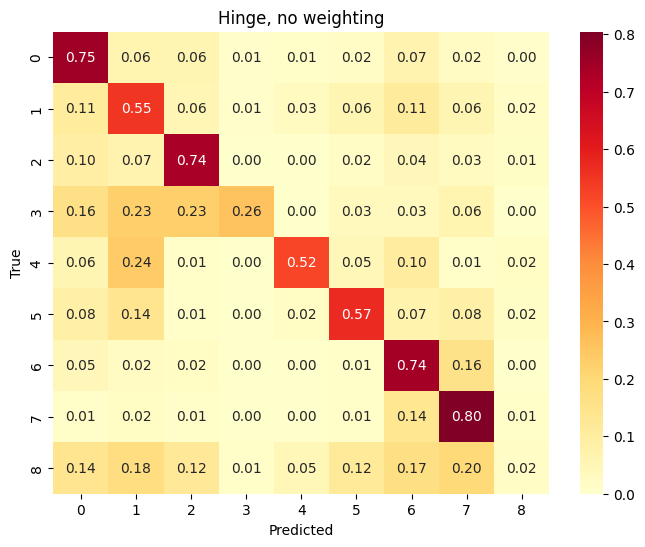

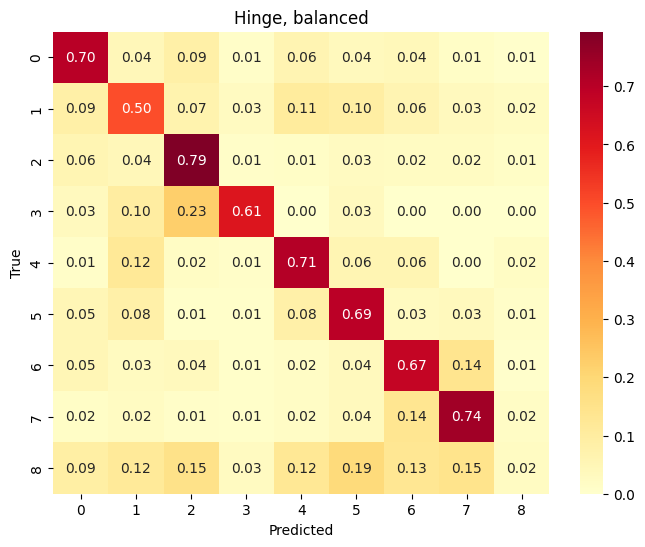

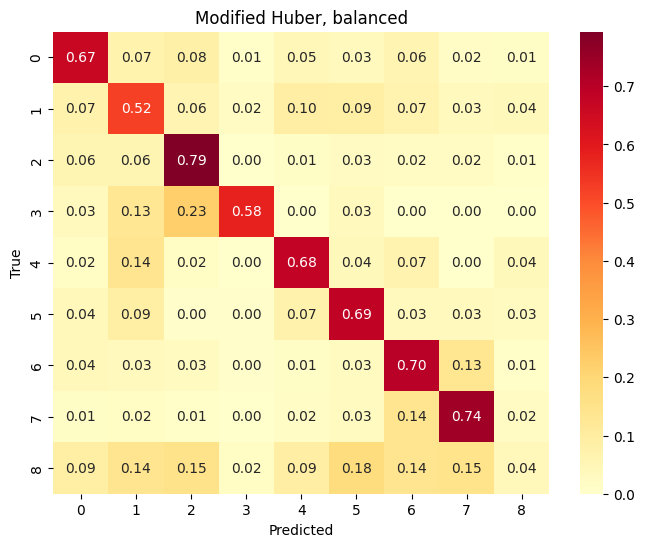

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='YlOrRd')
    plt.title(title)
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.show()

plot_cm(y_val, pred_a, "Hinge, no weighting")
plot_cm(y_val, pred_b, "Hinge, balanced")
plot_cm(y_val, pred_c, "Modified Huber, balanced")

In [20]:
with open('svm_model.pkl', 'wb') as f:
    pickle.dump(model_c, f)

results = {
    'Hinge (no weight)': f1_score(y_val, pred_a, average='macro'),
    'Hinge (balanced)': f1_score(y_val, pred_b, average='macro'),
    'Modified Huber (balanced)': f1_score(y_val, pred_c, average='macro'),
}
print(results)

{'Hinge (no weight)': 0.5373631321478874, 'Hinge (balanced)': 0.5249163329245224, 'Modified Huber (balanced)': 0.5391549426587264}


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

print("Dataset shape:", df.shape)
print("Label counts:")
print(df['label'].value_counts().sort_index())
print("Null text:", df['text'].isna().sum())

word_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    sublinear_tf=True,
    max_features=50000,
)
char_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_df=0.98,
    sublinear_tf=True,
    max_features=50000,
)
combined = FeatureUnion([
    ("word", word_vectorizer),
    ("char", char_vectorizer),
])

models = {
    "word_linear_svc": Pipeline([
        ("tfidf", word_vectorizer),
        ("classifier", LinearSVC(C=1.0, class_weight="balanced", random_state=42)),
    ]),
    "char_linear_svc": Pipeline([
        ("tfidf", char_vectorizer),
        ("classifier", LinearSVC(C=1.0, class_weight="balanced", random_state=42)),
    ]),
    "combined_linear_svc": Pipeline([
        ("features", combined),
        ("classifier", LinearSVC(C=1.0, class_weight="balanced", random_state=42)),
    ]),
}

for name, model in models.items():
    model.fit(train_df['text_clean'], y_train)
    pred = model.predict(val_df['text_clean'])
    score = accuracy_score(y_val, pred)
    print(f"{name}: accuracy={score:.4f}")
    print(classification_report(y_val, pred, digits=4, zero_division=0))

Dataset shape: (25000, 3)
Label counts:
label
0    3614
1    3357
2    2099
3     204
4     705
5    1730
6    5408
7    5321
8    2562
Name: count, dtype: int64
Null text: 0
word_linear_svc: accuracy=0.6339
              precision    recall  f1-score   support

           0     0.6927    0.7362    0.7138       542
           1     0.5490    0.5337    0.5412       504
           2     0.6204    0.7524    0.6801       315
           3     0.6154    0.5161    0.5614        31
           4     0.4841    0.5755    0.5259       106
           5     0.5356    0.6100    0.5704       259
           6     0.6988    0.7152    0.7069       811
           7     0.7469    0.7657    0.7562       798
           8     0.2222    0.1198    0.1557       384

    accuracy                         0.6339      3750
   macro avg     0.5739    0.5916    0.5791      3750
weighted avg     0.6146    0.6339    0.6217      3750

char_linear_svc: accuracy=0.6355
              precision    recall  f1-score   support


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

candidates = {
    "logreg_l2": LogisticRegression(C=2.0, max_iter=1000, random_state=42),
    "logreg_balanced": LogisticRegression(C=2.0, class_weight="balanced", max_iter=1000, random_state=42),
    "linear_svc": LinearSVC(C=1.0, class_weight="balanced", random_state=42),
}

for name, model in candidates.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    print(f"{name}: accuracy={accuracy_score(y_val, pred):.4f}")

logreg_l2: accuracy=0.6323
logreg_balanced: accuracy=0.6131
linear_svc: accuracy=0.6128
